## imports

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

In [2]:
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# use new data

In [4]:
modelname = 'varynode'
iepoch=51
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 22222  # for eval plot 
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]

# use existing data

In [6]:
all_reward_res=open_pickle_file('figdata/vary node p.pkl')

In [10]:
res=all_reward_res[1]

In [14]:
title = 'lick prob Vs noise prob Vs time'

fig= plt.figure()

for inode, node in enumerate(node_list):
    all_episode_data=res[inode]


    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    if title == 'att prob Vs noise prob Vs time':
        data = (attention_prob_list, noise_prob_list)
    elif title == 'lick prob Vs noise prob Vs time':
        data = (lick_prob_list, noise_prob_list)
    elif title == 'att entropy Vs noise prob Vs time':
        data = (attention_entropy_list, noise_prob_list)
    elif title == 'lick entropy Vs noise prob Vs time':
        data = (lick_entropy_list, noise_prob_list)
    else:
        print('Error: Change title!')

    if title in ['att prob Vs noise prob Vs time', 'lick prob Vs noise prob Vs time', 'att entropy Vs noise prob Vs time', 'lick entropy Vs noise prob Vs time']:
        no_ticks = 3
        no_prob_bins = 10
        min_display_time = 0
        max_display_time = 50
        prob_bin_vals = np.linspace(0,1,11)
        display_tick_inds = np.linspace(
            0, len(prob_bin_vals) - 1, no_ticks).astype(int)

        (metric_list, noise_prob_list) = data
        max_time = max([len(metric_val) for metric_val in metric_list])

        prob_dict = {}
        for episode_ind in range(len(noise_prob_list)):
            for time_ind in range(len(noise_prob_list[episode_ind])):
                prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)), time_ind), [
                ]).append(metric_list[episode_ind][time_ind])

        avg_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        sem_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
        for (noise_prob_bin, time_ind), metric_list in prob_dict.items():
            avg_metric_matrix[noise_prob_bin, time_ind] = np.mean(metric_list)
            sem_metric_matrix[noise_prob_bin, time_ind] = np.std(
                metric_list)/np.sqrt(len(metric_list))
            count_matrix[noise_prob_bin, time_ind] = len(metric_list)

        mean_list = np.nanmean(avg_metric_matrix, 1)
        sample_size_list = np.sum(count_matrix, 1)
        sem_list = np.nanstd(avg_metric_matrix, 1)/np.sqrt(sample_size_list)

        # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
        y=mean_list[::-1]
        valid_indices = np.where(~np.isnan(y))[0]
        plt.plot(y[valid_indices],
                 label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx], linewidth=3)
        ax=plt.gca()
        centerax(ax)
        plt.yticks([0,0.5,1], ['0','','1'])
        plt.xlabel('signal prob.')
        if title == 'att prob Vs noise prob Vs time':
            plt.ylabel('Average att prob')
        elif title == 'lick prob Vs noise prob Vs time':
            plt.ylabel('Average lick prob')
        plt.xticks(display_tick_inds, [str(prob_bin_vals[ind])[
                   :4] for ind in display_tick_inds])
        plt.xlabel('signal prob.')
color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


plt.title(title)
# quickleg(ax)
quicksave(f'{title}', 'plot sigmoid', fig=fig)
plt.show()

ValueError: too many values to unpack (expected 6)

<Figure size 640x480 with 0 Axes>

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/4212878584.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/4212878584.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/4212878584.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: Runtim

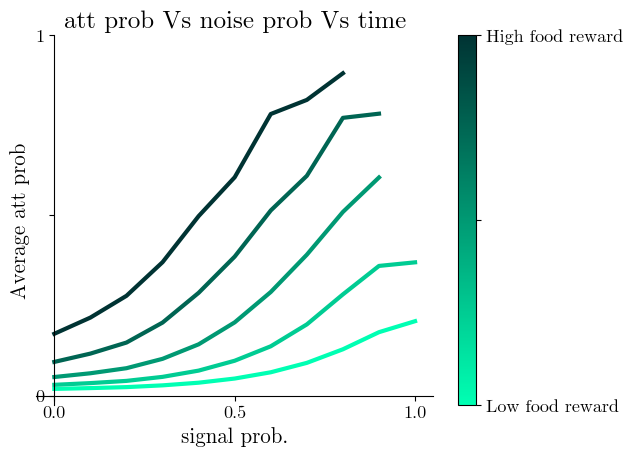

In [113]:
title = 'att prob Vs noise prob Vs time'


fig= plt.figure()
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len, attention_entropy_list, lick_entropy_list = all_reward_res[
        food_reward_idx]

    if title == 'att prob Vs noise prob Vs time':
        data = (attention_prob_list, noise_prob_list)
    elif title == 'lick prob Vs noise prob Vs time':
        data = (lick_prob_list, noise_prob_list)
    elif title == 'att entropy Vs noise prob Vs time':
        data = (attention_entropy_list, noise_prob_list)
    elif title == 'lick entropy Vs noise prob Vs time':
        data = (lick_entropy_list, noise_prob_list)
    else:
        print('Error: Change title!')

    if title in ['att prob Vs noise prob Vs time', 'lick prob Vs noise prob Vs time', 'att entropy Vs noise prob Vs time', 'lick entropy Vs noise prob Vs time']:
        no_ticks = 3
        no_prob_bins = 10
        min_display_time = 0
        max_display_time = 50
        prob_bin_vals = np.linspace(0,1,11)
        display_tick_inds = np.linspace(
            0, len(prob_bin_vals) - 1, no_ticks).astype(int)

        (metric_list, noise_prob_list) = data
        max_time = max([len(metric_val) for metric_val in metric_list])

        prob_dict = {}
        for episode_ind in range(len(noise_prob_list)):
            for time_ind in range(len(noise_prob_list[episode_ind])):
                prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)), time_ind), [
                ]).append(metric_list[episode_ind][time_ind])

        avg_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        sem_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
        for (noise_prob_bin, time_ind), metric_list in prob_dict.items():
            avg_metric_matrix[noise_prob_bin, time_ind] = np.mean(metric_list)
            sem_metric_matrix[noise_prob_bin, time_ind] = np.std(
                metric_list)/np.sqrt(len(metric_list))
            count_matrix[noise_prob_bin, time_ind] = len(metric_list)

        mean_list = np.nanmean(avg_metric_matrix, 1)
        sample_size_list = np.sum(count_matrix, 1)
        sem_list = np.nanstd(avg_metric_matrix, 1)/np.sqrt(sample_size_list)

        # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
        y=mean_list[::-1]
        valid_indices = np.where(~np.isnan(y))[0]
        plt.plot(y[valid_indices],  
                 label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx], linewidth=3)
        ax=plt.gca()
        centerax(ax)
        plt.yticks([0,0.5,1], ['0','','1'])
        plt.xlabel('signal prob.')
        if title == 'att prob Vs noise prob Vs time':
            plt.ylabel('Average att prob')
        elif title == 'lick prob Vs noise prob Vs time':
            plt.ylabel('Average lick prob')
        plt.xticks(display_tick_inds, [str(prob_bin_vals[ind])[
                   :4] for ind in display_tick_inds])
        plt.xlabel('signal prob.')

color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

plt.title(title)
quicksave(f'{title}', 'plot sigmoid', fig=fig)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/1132812902.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/1132812902.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/1132812902.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: Runtim

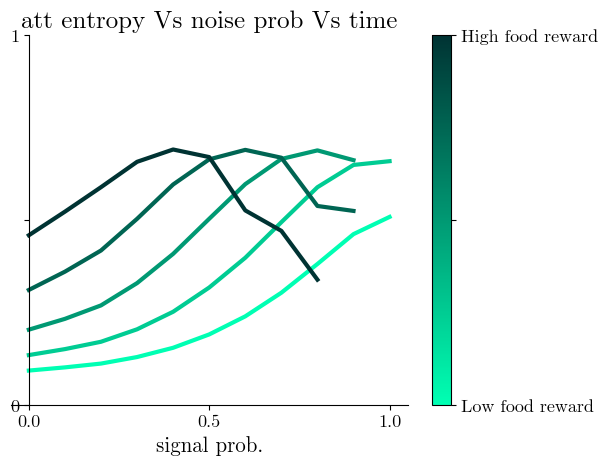

In [114]:

title = 'att entropy Vs noise prob Vs time'


fig= plt.figure()
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len, attention_entropy_list, lick_entropy_list = all_reward_res[
        food_reward_idx]

    if title == 'att prob Vs noise prob Vs time':
        data = (attention_prob_list, noise_prob_list)
    elif title == 'lick prob Vs noise prob Vs time':
        data = (lick_prob_list, noise_prob_list)
    elif title == 'att entropy Vs noise prob Vs time':
        data = (attention_entropy_list, noise_prob_list)
    elif title == 'lick entropy Vs noise prob Vs time':
        data = (lick_entropy_list, noise_prob_list)
    else:
        print('Error: Change title!')

    if title in ['att prob Vs noise prob Vs time', 'lick prob Vs noise prob Vs time', 'att entropy Vs noise prob Vs time', 'lick entropy Vs noise prob Vs time']:
        no_ticks = 3
        no_prob_bins = 10
        min_display_time = 0
        max_display_time = 50
        prob_bin_vals = np.linspace(0,1,11)
        display_tick_inds = np.linspace(
            0, len(prob_bin_vals) - 1, no_ticks).astype(int)

        (metric_list, noise_prob_list) = data
        max_time = max([len(metric_val) for metric_val in metric_list])

        prob_dict = {}
        for episode_ind in range(len(noise_prob_list)):
            for time_ind in range(len(noise_prob_list[episode_ind])):
                prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)), time_ind), [
                ]).append(metric_list[episode_ind][time_ind])

        avg_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        sem_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
        for (noise_prob_bin, time_ind), metric_list in prob_dict.items():
            avg_metric_matrix[noise_prob_bin, time_ind] = np.mean(metric_list)
            sem_metric_matrix[noise_prob_bin, time_ind] = np.std(
                metric_list)/np.sqrt(len(metric_list))
            count_matrix[noise_prob_bin, time_ind] = len(metric_list)

        mean_list = np.nanmean(avg_metric_matrix, 1)
        sample_size_list = np.sum(count_matrix, 1)
        sem_list = np.nanstd(avg_metric_matrix, 1)/np.sqrt(sample_size_list)

        # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
        y=mean_list[::-1]
        valid_indices = np.where(~np.isnan(y))[0]
        plt.plot(y[valid_indices],  
                 label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx], linewidth=3)
        ax=plt.gca()
        centerax(ax)
        plt.yticks([0,0.5,1], ['0','','1'])
        plt.xlabel('signal prob.')
        if title == 'att prob Vs noise prob Vs time':
            plt.ylabel('Average att prob')
        elif title == 'lick prob Vs noise prob Vs time':
            plt.ylabel('Average lick prob')
        plt.xticks(display_tick_inds, [str(prob_bin_vals[ind])[
                   :4] for ind in display_tick_inds])
        plt.xlabel('signal prob.')
color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

plt.title(title)
quicksave(f'{title}', 'plot sigmoid', fig=fig)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/279174054.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/279174054.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/279174054.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix, 1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWa

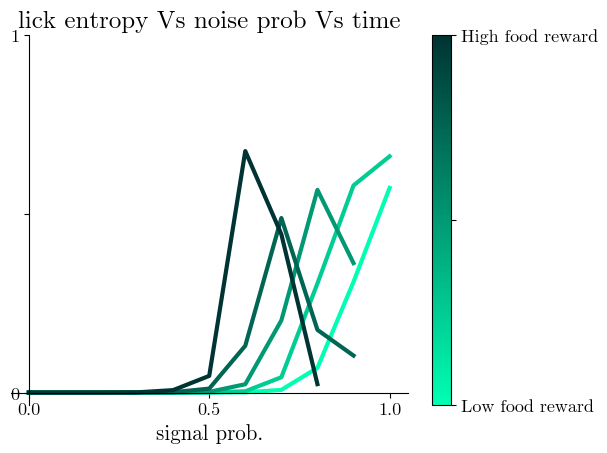

In [115]:
title = 'lick entropy Vs noise prob Vs time'


fig= plt.figure()
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len, attention_entropy_list, lick_entropy_list = all_reward_res[
        food_reward_idx]

    if title == 'att prob Vs noise prob Vs time':
        data = (attention_prob_list, noise_prob_list)
    elif title == 'lick prob Vs noise prob Vs time':
        data = (lick_prob_list, noise_prob_list)
    elif title == 'att entropy Vs noise prob Vs time':
        data = (attention_entropy_list, noise_prob_list)
    elif title == 'lick entropy Vs noise prob Vs time':
        data = (lick_entropy_list, noise_prob_list)
    else:
        print('Error: Change title!')

    if title in ['att prob Vs noise prob Vs time', 'lick prob Vs noise prob Vs time', 'att entropy Vs noise prob Vs time', 'lick entropy Vs noise prob Vs time']:
        no_ticks = 3
        no_prob_bins = 10
        min_display_time = 0
        max_display_time = 50
        prob_bin_vals = np.linspace(0,1,11)
        display_tick_inds = np.linspace(
            0, len(prob_bin_vals) - 1, no_ticks).astype(int)

        (metric_list, noise_prob_list) = data
        max_time = max([len(metric_val) for metric_val in metric_list])

        prob_dict = {}
        for episode_ind in range(len(noise_prob_list)):
            for time_ind in range(len(noise_prob_list[episode_ind])):
                prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)), time_ind), [
                ]).append(metric_list[episode_ind][time_ind])

        avg_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        sem_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
        for (noise_prob_bin, time_ind), metric_list in prob_dict.items():
            avg_metric_matrix[noise_prob_bin, time_ind] = np.mean(metric_list)
            sem_metric_matrix[noise_prob_bin, time_ind] = np.std(
                metric_list)/np.sqrt(len(metric_list))
            count_matrix[noise_prob_bin, time_ind] = len(metric_list)

        mean_list = np.nanmean(avg_metric_matrix, 1)
        sample_size_list = np.sum(count_matrix, 1)
        sem_list = np.nanstd(avg_metric_matrix, 1)/np.sqrt(sample_size_list)

        # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
        y=mean_list[::-1]
        valid_indices = np.where(~np.isnan(y))[0]
        plt.plot(y[valid_indices],  
                 label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=cmap(np.linspace(0, 1, len(food_reward_list)))[food_reward_idx], linewidth=3)
        ax=plt.gca()
        centerax(ax)
        plt.yticks([0,0.5,1], ['0','','1'])
        plt.xlabel('signal prob.')
        if title == 'att prob Vs noise prob Vs time':
            plt.ylabel('Average att prob')
        elif title == 'lick prob Vs noise prob Vs time':
            plt.ylabel('Average lick prob')
        plt.xticks(display_tick_inds, [str(prob_bin_vals[ind])[
                   :4] for ind in display_tick_inds])
        plt.xlabel('signal prob.')
color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

plt.title(title)
quicksave(f'{title}', 'plot sigmoid', fig=fig)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/271217416.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=2, common_norm=False, color=cmap(
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/271217416.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=2, common_norm=False, color=cmap(
webf NOT subset; don't know how to subset; dropped


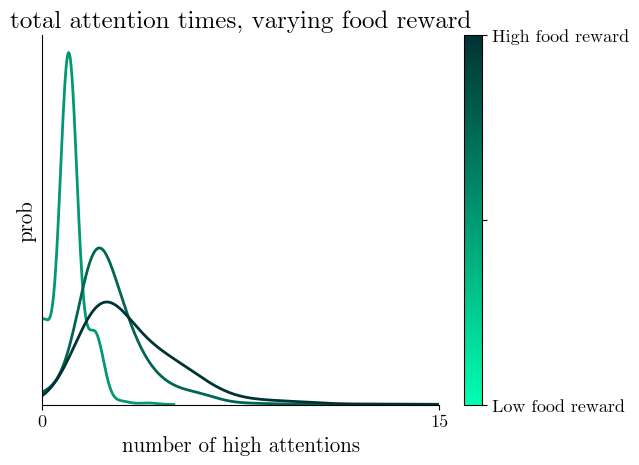

In [116]:
# total attn time
fig= plt.figure()
for food_reward_idx in all_reward_res.keys():

    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len, attention_entropy_list, lick_entropy_list = all_reward_res[
        food_reward_idx]

    sns.kdeplot([len(a) for a in att_time_list], label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=2, common_norm=False, color=cmap(
        np.linspace(0, 1, len(all_reward_res)))[food_reward_idx])


color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


plt.xlabel('number of high attentions')
plt.ylabel('prob')
plt.title(f'total attention times, varying food reward')
# plt.ylim(0,1500)

centerax(plt.gca())
plt.yticks([])
plt.xlim(0, 15)
plt.xticks([0, 15])
quicksave('total att time', 'plot sigmoid', fig=fig)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/510664746.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(plotdata, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=1, common_norm=False, color=cmap(
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2732/510664746.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(plotdata, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=1, common_norm=False, color=cmap(
webf NOT subset; don't know how to subset; dropped


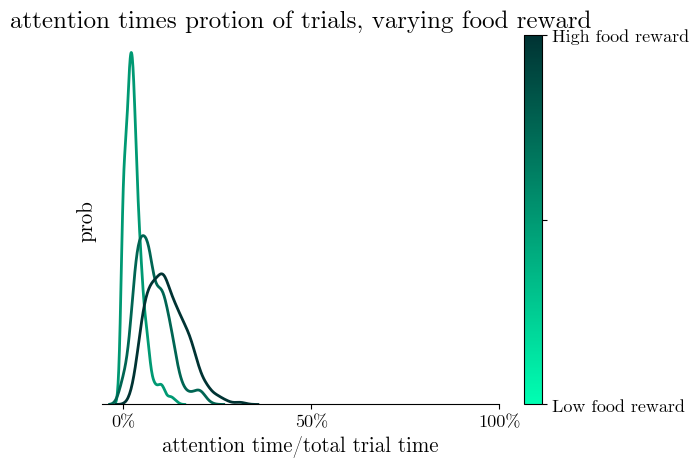

In [117]:
# attn time percent of trial len
fig= plt.figure()
for food_reward_idx in all_reward_res.keys():

    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len, attention_entropy_list, lick_entropy_list = all_reward_res[
        food_reward_idx]
    plotdata=[len(a)/b for a,b in zip(att_time_list,trial_len)]
    sns.kdeplot(plotdata, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=1, common_norm=False, color=cmap(
        np.linspace(0, 1, len(all_reward_res)))[food_reward_idx])


color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)


# plt.xlabel('number of high attentions')
plt.ylabel('prob')
plt.title(f'attention times protion of trials, varying food reward')
# # plt.ylim(0,1500)
# centerax(plt.gca())
plt.yticks([])
plt.gca().spines['left'].set_visible(False)
# plt.xlim(0, 1)
plt.xticks([0, 0.5, 1], ['0%', '50%', '100%'])
plt.xlabel('attention time/total trial time')
quicksave('total att time percent', 'plot sigmoid', fig=fig)
plt.show()